# Linear Classification

## Imports

In [4]:
import numpy as np
import matplotlib.pyplot as plt

## Generate data

the model will classify points in 2D into 2 seperate classes. \
class 0: cluster centered around (-2,-2)
- $x ∼ \mathcal{N}(\mu=(-2,-2), \Sigma=I)$

class 1: cluster centered around (2,2)
- $x∼\mathcal{N}(\mu=(2,2), \Sigma=I)$

In [90]:
# generate data shape
# x: (500,2), 250 from each class
# y: (500,), correct class (0/1) for all 500 x

n = 250 # n samples

In [91]:
def make_data(n=100):
    c0 = np.random.randn(n,2) + np.array([-2,-2])
    c1 = np.random.randn(n,2) + np.array([2,2])

    x = np.vstack([c0,c1])
    y = np.hstack([np.zeros(n), np.ones(n)])

    return x,y

In [92]:
x,y = make_data(n)
print(x.shape)
print(y.shape)

(500, 2)
(500,)


In [93]:
def plot_data(x,y):
    c0 = x[y==0]
    c1 = x[y==1]

    plt.scatter(c0[:,0], c0[:,1], label="class 0")
    plt.scatter(c1[:,0], c1[:,1], label="class 1")
    plt.legend()
    plt.title("dataset")
    plt.show()

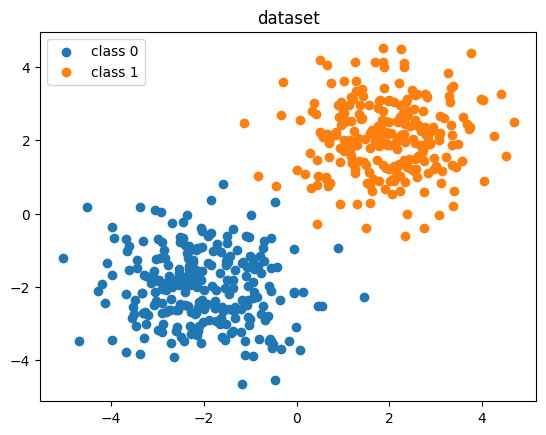

In [94]:
# visualise data
plot_data(x,y)

## Model implementation

In [95]:
# sigmoid activation function
def sig(z):
    # clip pre-activation to avoid overflow
    z = np.clip(z, -500, 500)
    return 1/(1+np.exp(-z))

In [96]:
# forward pass
def forward(x, w, b):
    # x: (nsamples, nclasses) | w,b: (nclasses,)
    z = x @ w + b
    p = sig(z)
    return p

## Loss function

In [97]:
# we minimise binary-cross entropy
# L = -1/n . sum { y.log p + (1-y)log(1-p) }
def loss(y,p):
    eps = 1e-15 # noise
    # clip probs before taking log
    p = np.clip(p, eps, 1-eps)
    # terms
    t1 = y*np.log(p)
    t2 = (1-y)*np.log(1-p)

    return -np.mean(t1 + t2)

## Gradient derivation

In [98]:
# dL/dw = dL/dp . dp/dz . dz/dw = dL/dz . dz/d{w,b}
# dw = (p-y)x | db = (p-y)
# matrix versions: dw = mean{(p-y)x}, db = mean{(p-y)} | mean = (1/n)sum(_)
def grads(x,y,p):
    # x: (nsamples, nclasses), y: (nsamples,), p: (nsamples,)
    dz = p - y
    dw = (1/x.shape[0]) * x.T @ dz
    db = np.mean(dz)

    return dw,db

## Training the model

In [99]:
def train(x, y, lr=0.1, steps=1000):
    # parameter setup
    w = np.zeros(x.shape[1]) # nclasses
    b = 0
    y = y.reshape(-1)
    
    Ls = [] # losses
    for s in range(steps):
        p = forward(x,w,b)
        Ls.append(loss(y,p))

        dw, db = grads(x,y,p)
        # gradient descent
        w -= lr * dw
        b -= lr * db

    return w,b,Ls

In [100]:
# train the model
w,b,Ls = train(x,y)

## Analysis

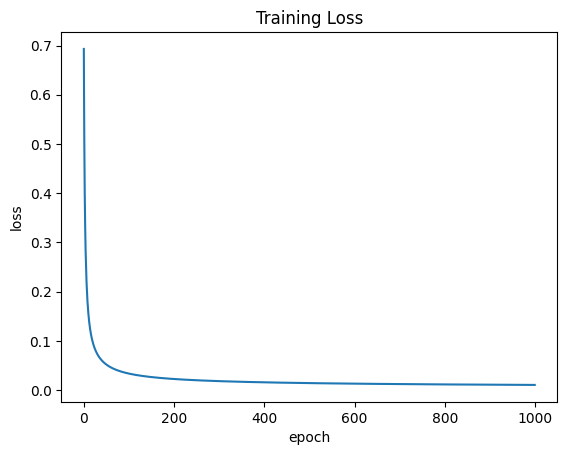

In [101]:
plt.plot(Ls)
plt.title("Training Loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

In [105]:
# final loss
Ls[-1]

0.010399522880930377

In [106]:
# weights
w

array([1.86991332, 2.12529707])

In [107]:
# bias
b

0.02573920142068394

In [112]:
def predict(x,w,b):
    p = forward(x,w,b)
    return (p >= 0.5).astype(int)

In [113]:
# create a new dataset for testing
xte, yte = make_data(100)

In [135]:
# get predictions
ps = predict(xte,w,b)

# calculate Accuracy
acc = (ps==yte).mean()
print("Accuracy (testing data):",acc)

Accuracy (testing data): 1.0


In [136]:
# visualise descision boundary of data
def plot_bound(x, y, w, b, label="training data"): # label: training or testing

    class0 = x[y==0]
    class1 = x[y==1]

    plt.scatter(class0[:,0], class0[:,1])
    plt.scatter(class1[:,0], class1[:,1])

    x_vals = np.linspace(-5,5,100)
    y_vals = -(w[0]*x_vals + b)/w[1]

    plt.plot(x_vals, y_vals, color="black")

    plt.title(f"Decision Boundary: {label}")
    plt.show()

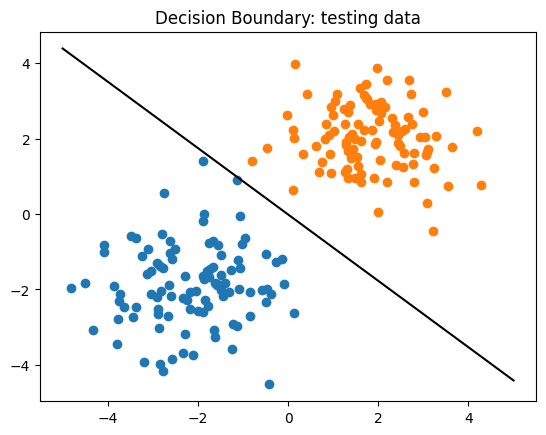

In [137]:
plot_bound(xte,yte,w,b, "testing data")

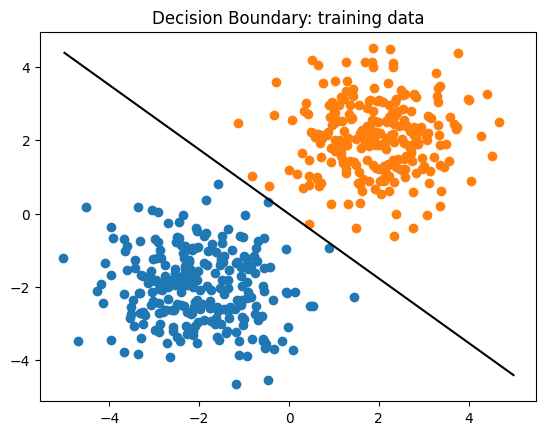

In [138]:
# descision bound for training data
plot_bound(x,y,w,b)